**PROJECT-BASED INTERNSHIP VINIX7**

**Modul 3: Statistik & Probabilitas untuk Data Science**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('all_months_clean.csv', sep=';')
df = df.dropna(subset=['Total Pembayaran', 'total_weight_gr', 'Perkiraan Ongkos Kirim', 'Metode Pembayaran'])

print(f"Jumlah baris data setelah dibersihkan: {len(df)}")

Jumlah baris data setelah dibersihkan: 20848


Output ini menunjukkan tahap awal penyiapan data. Sistem telah membaca file dataset dan membuang baris-baris transaksi yang datanya tidak lengkap atau kosong pada kolom-kolom yang akan diteliti, yaitu 'Total Pembayaran', 'total_weight_gr', 'Perkiraan Ongkos Kirim', dan 'Metode Pembayaran'. Hasilnya, didapatkan 20.848 baris transaksi yang valid dan bersih.

In [ ]:
print("Statistik Total Pembayaran:\n", df['Total Pembayaran'].describe())
print("\nStatistik Berat (gr):\n", df['total_weight_gr'].describe())

Statistik Total Pembayaran:
 count    2.084800e+04
mean     5.068360e+04
std      1.440193e+05
min      0.000000e+00
25%      1.348000e+04
50%      2.180000e+04
75%      4.160000e+04
max      3.403591e+06
Name: Total Pembayaran, dtype: float64

Statistik Berat (gr):
 count     20848.000000
mean       2004.529691
std        7106.357515
min          10.000000
25%         300.000000
50%         500.000000
75%        1600.000000
max      375000.000000
Name: total_weight_gr, dtype: float64


**Total Pembayaran:** Rata-rata (mean) transaksi bernilai sekitar Rp 50.683. Namun, nilai tengahnya (median) jauh lebih kecil, yaitu Rp 21.800. Terdapat rentang yang sangat ekstrem hingga nilai maksimum mencapai Rp 3.403.591. Terdapat nilai minimum Rp 0 yang kemungkinan menandakan adanya pesanan yang dibayar penuh menggunakan voucher, subsidi, atau koin e-commerce.

**Berat Barang:** Rata-rata berat barang per pesanan adalah 2.004 gram, dengan nilai tengah hanya 500 gram. Sama seperti pembayaran, terdapat nilai maksimum yang sangat ekstrem hingga 375.000 gram.

**Kesimpulan:** Jarak yang sangat jauh antara nilai mean dan median pada kedua kolom, serta tingginya nilai maksimum dan standar deviasi, menjadi indikasi awal bahwa data sangat melenceng ke kanan (right-skewed) dan memiliki banyak data outlier.

In [ ]:
z_scores = np.abs(stats.zscore(df['Total Pembayaran']))
outlier_bayar = df[z_scores > 3]

print(f"Jumlah Outlier Total Pembayaran (Z > 3): {len(outlier_bayar)}")

z_scores_berat = np.abs(stats.zscore(df['total_weight_gr']))
outlier_berat = df[z_scores_berat > 3]
print(f"Jumlah Outlier Berat Barang (Z > 3): {len(outlier_berat)}")

Jumlah Outlier Total Pembayaran (Z > 3): 232
Jumlah Outlier Berat Barang (Z > 3): 254


Berdasarkan perhitungan menggunakan metode Z-Score, nilai dengan penyimpangan lebih dari 3 standar deviasi (Z > 3) dikategorikan sebagai outlier atau data ekstrem.

**Outlier Total Pembayaran:** Terdapat 232 pesanan yang nilai pembayarannya sangat ekstrem dibandingkan mayoritas transaksi lainnya. Ini bisa jadi merupakan transaksi pembelian barang mewah, pembelian grosir/borongan, atau error pencatatan.

**Outlier Berat Barang:** Terdapat 254 pesanan dengan berat yang sangat tidak wajar (ekstrem) dibandingkan rata-rata pesanan reguler. Ini mungkin mewakili pembelian barang berdimensi sangat besar/berat (seperti furnitur atau elektronik besar).

**Kesimpulan:** Kehadiran outlier ini mengonfirmasi mengapa nilai rata-rata (mean) pada statistik sebelumnya tertarik jauh lebih tinggi dibandingkan nilai tengahnya (median).

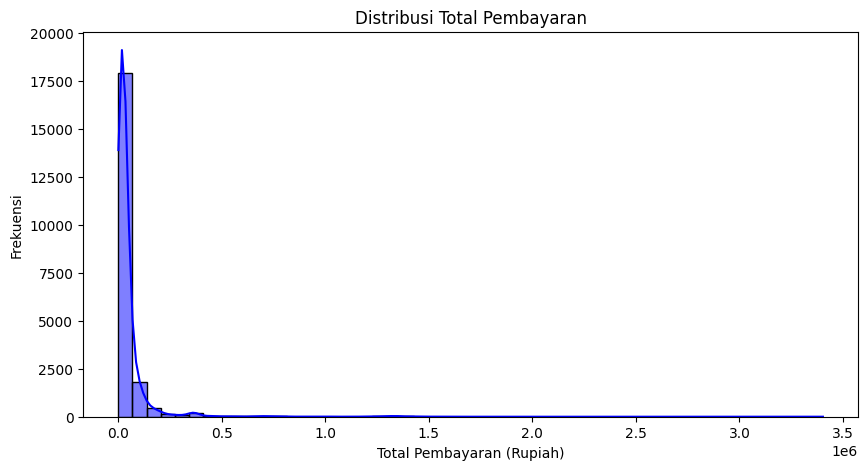

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Total Pembayaran'], kde=True, bins=50, color='blue')
plt.title('Distribusi Total Pembayaran')
plt.xlabel('Total Pembayaran (Rupiah)')
plt.ylabel('Frekuensi')
plt.show()

**Distribusi Total Pembayaran:** Berdasarkan visualisasi histogram, data Total Pembayaran tidak terdistribusi secara normal. Kurva menunjukkan bentuk yang sangat melenceng ke kanan (right-skewed atau positive skew). Hal ini menunjukkan bahwa mayoritas pelanggan berbelanja dengan nominal kecil hingga menengah (menumpuk di sisi kiri grafik). Ekor panjang di sebelah kanan mengonfirmasi keberadaan outlier yang kita temukan sebelumnya, yaitu segelintir pelanggan yang melakukan transaksi dengan nominal sangat besar hingga lebih dari Rp 3 Juta.

In [ ]:
spaylater = df[df['Metode Pembayaran'] == 'SPayLater']['Total Pembayaran']
cod = df[df['Metode Pembayaran'] == 'COD (Bayar di Tempat)']['Total Pembayaran']

t_stat, p_val = stats.ttest_ind(spaylater, cod, equal_var=False, nan_policy='omit')
print(f"Hasil T-Test Metode Pembayaran (SPayLater vs COD):\nT-Statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

Hasil T-Test Metode Pembayaran (SPayLater vs COD):
T-Statistic: 5.8865, P-value: 0.0000


**Hipotesis Nol (H0):** Tidak ada perbedaan rata-rata Total Pembayaran yang signifikan antara pelanggan yang menggunakan metode SPayLater dan COD.

**Hipotesis Alternatif (H1):** Terdapat perbedaan rata-rata Total Pembayaran yang signifikan antara pelanggan yang menggunakan metode SPayLater dan COD.

**Kesimpulan:** Berdasarkan hasil uji T dua sampel independen, didapatkan nilai P-value sebesar 0.0000. Karena nilai P-value jauh lebih kecil dari tingkat signifikansi, maka kita Menolak H0. Lalu terdapat perbedaan nominal belanja yang sangat signifikan secara statistik antara kedua metode pembayaran tersebut. Nilai T-Statistic yang positif juga mengindikasikan bahwa rata-rata pembelanjaan menggunakan SPayLater lebih tinggi dibandingkan dengan COD.

In [ ]:
X = df['total_weight_gr']
y = df['Perkiraan Ongkos Kirim']

X = sm.add_constant(X)
model_regresi = sm.OLS(y, X).fit()

print("Hasil Regresi Linear (Berat vs Ongkir):")
print(model_regresi.summary())

Hasil Regresi Linear (Berat vs Ongkir):
                              OLS Regression Results                              
Dep. Variable:     Perkiraan Ongkos Kirim   R-squared:                       0.162
Model:                                OLS   Adj. R-squared:                  0.162
Method:                     Least Squares   F-statistic:                     4037.
Date:                    Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                            10:02:53   Log-Likelihood:            -2.3782e+05
No. Observations:                   20848   AIC:                         4.757e+05
Df Residuals:                       20846   BIC:                         4.757e+05
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

**Arti Koefisien:** Pada tabel hasil regresi, nilai coefficient untuk variabel total_weight_gr adalah 1.3485 dengan nilai p-value 0.000. Ini berarti bahwa setiap kenaikan 1 gram berat barang, perkiraan ongkos kirim akan bertambah sebesar Rp 1,35.

**Nilai Konstanta:** Nilai konstanta sebesar 1.572e+04 atau sekitar Rp 15.720 menunjukkan estimasi ongkos kirim dasar sebelum dipengaruhi oleh berat barang.

**Mini Report**

Berdasarkan hasil uji T yang membandingkan nilai transaksi antara metode pembayaran SPayLater dan COD (Bayar di Tempat), diperoleh nilai T-statistic sebesar 5.8865 dengan nilai p-value sebesar 0.0000. Karena nilai p-value lebih kecil dari tingkat signifikansi, maka kita menolak H0, yang dapat disimpulkan bahwa terdapat perbedaan yang signifikan secara statistik antara rata-rata nilai transaksi menggunakan SPayLater dan COD. Nilai T=statistic yang positif juga mengindikasikan bahwa rata-rata transaksi menggunakan SPayLater lebih tinggi dibandingkan COD. Hal ini menunjukkan bahwa metode pembayaran memiliki pengaruh terhadap nilai transaksi yang terjadi. Dengan adanya perbedaan yang signifikan ini, perusahaan dapat mempertimbangkan untuk mendorong penggunaan SPayLater melalui promo atau insentif tertentu, karena metode pembayaran menggunakan SPayLater berpotensi memberikan kontribusi terhadap peningkatan nilai transaksi dibandingkan dengan metode pembayaran COD.

Selain itu, hasil analisis regresi linear antara berat barang dan perkiraan ongkos kirim menunjukkan hubungan yang positif, dengan koefisien sebesar 1.3485. Hal ini berarti setiap kenaikan 1 gram berat barang, diperkirakan akan meningkatkan ongkos kirim sebesar Rp 1,35. Namun, nilai R-squared sebesar 0.162 menunjukkan bahwa berat barang hanya mampu menjelaskan sekitar 16.2% variasi dalam ongkos kirim, sehingga akurasinya masih lebih rendah jika digunakan sebagai satu-satunya prediktor. Dengan demikian, meskipun berat barang memiliki pengaruh terhadap ongkos kirim, faktor ini belum cukup kuat untuk memprediksi ongkos kirim secara akurat, dan kemungkinan terdapat faktor lain yang juga mempengaruhi ongkos kirim, seperti jarak pengiriman, lokasi tujuan, atau jenis layanan kurir.